# Decision Tree for Classification


Build a decision tree classifier to predict flower species using the Iris dataset.

**Tasks:**
1. Train a decision tree on a labeled dataset
2. Visualize the tree structure
3. Prune the tree to prevent overfitting
4. Evaluate the model using classification metrics (accuracy and F1-score)

## 1. Import Required Libraries

In [53]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Decision tree and model evaluation
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             f1_score, precision_score, recall_score)

# For visualizing the tree
from sklearn import tree

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')



## 2. Load and Explore the Dataset

In [54]:
# Load the Iris dataset
df = pd.read_csv('dataset/iris.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nTarget Variable Distribution:")
print(df['species'].value_counts())

Dataset Shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical Summary:
       sepal_length  sepal_width  petal_length  petal_width
count    150.00000

In [55]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Number of duplicate rows: 3


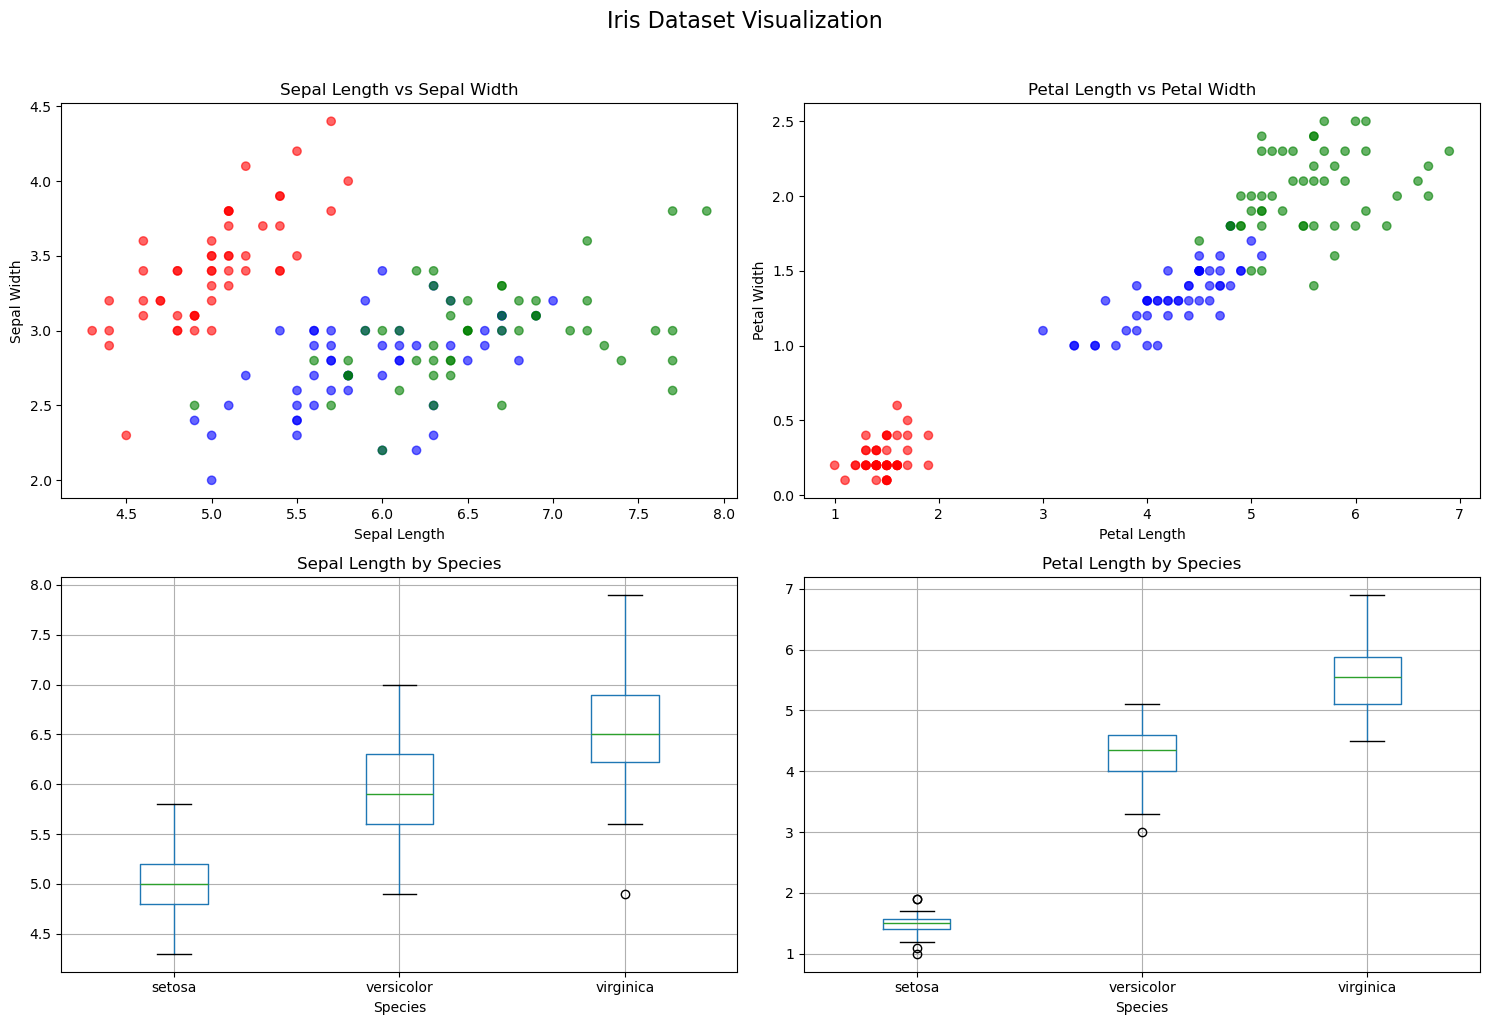

In [56]:
# Visualize the dataset
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Pairplot-like visualization
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

# Scatter plots
axes[0, 0].scatter(df['sepal_length'], df['sepal_width'], c=df['species'].map(colors), alpha=0.6)
axes[0, 0].set_xlabel('Sepal Length')
axes[0, 0].set_ylabel('Sepal Width')
axes[0, 0].set_title('Sepal Length vs Sepal Width')

axes[0, 1].scatter(df['petal_length'], df['petal_width'], c=df['species'].map(colors), alpha=0.6)
axes[0, 1].set_xlabel('Petal Length')
axes[0, 1].set_ylabel('Petal Width')
axes[0, 1].set_title('Petal Length vs Petal Width')

# Box plots
df.boxplot(column='sepal_length', by='species', ax=axes[1, 0])
axes[1, 0].set_title('Sepal Length by Species')
axes[1, 0].set_xlabel('Species')

df.boxplot(column='petal_length', by='species', ax=axes[1, 1])
axes[1, 1].set_title('Petal Length by Species')
axes[1, 1].set_xlabel('Species')

plt.suptitle('Iris Dataset Visualization', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 3. Prepare Data for Training

In [57]:
# Separate features and target variable
X = df.drop('species', axis=1)
y = df['species']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("\nTarget classes:", y.unique())

Features shape: (150, 4)
Target shape: (150,)

Feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target classes: ['setosa' 'versicolor' 'virginica']


In [58]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining set class distribution:")
print(y_train.value_counts())
print("\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 120
Testing set size: 30

Training set class distribution:
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

Testing set class distribution:
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


## 4. Train Decision Tree Classifier (Without Pruning)

In [59]:
# Create and train the decision tree classifier (unpruned)
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

print("Decision Tree trained successfully!")
print(f"\nTree Depth: {dt_unpruned.get_depth()}")
print(f"Number of Leaves: {dt_unpruned.get_n_leaves()}")

Decision Tree trained successfully!

Tree Depth: 5
Number of Leaves: 8


## 5. Visualize the Decision Tree Structure

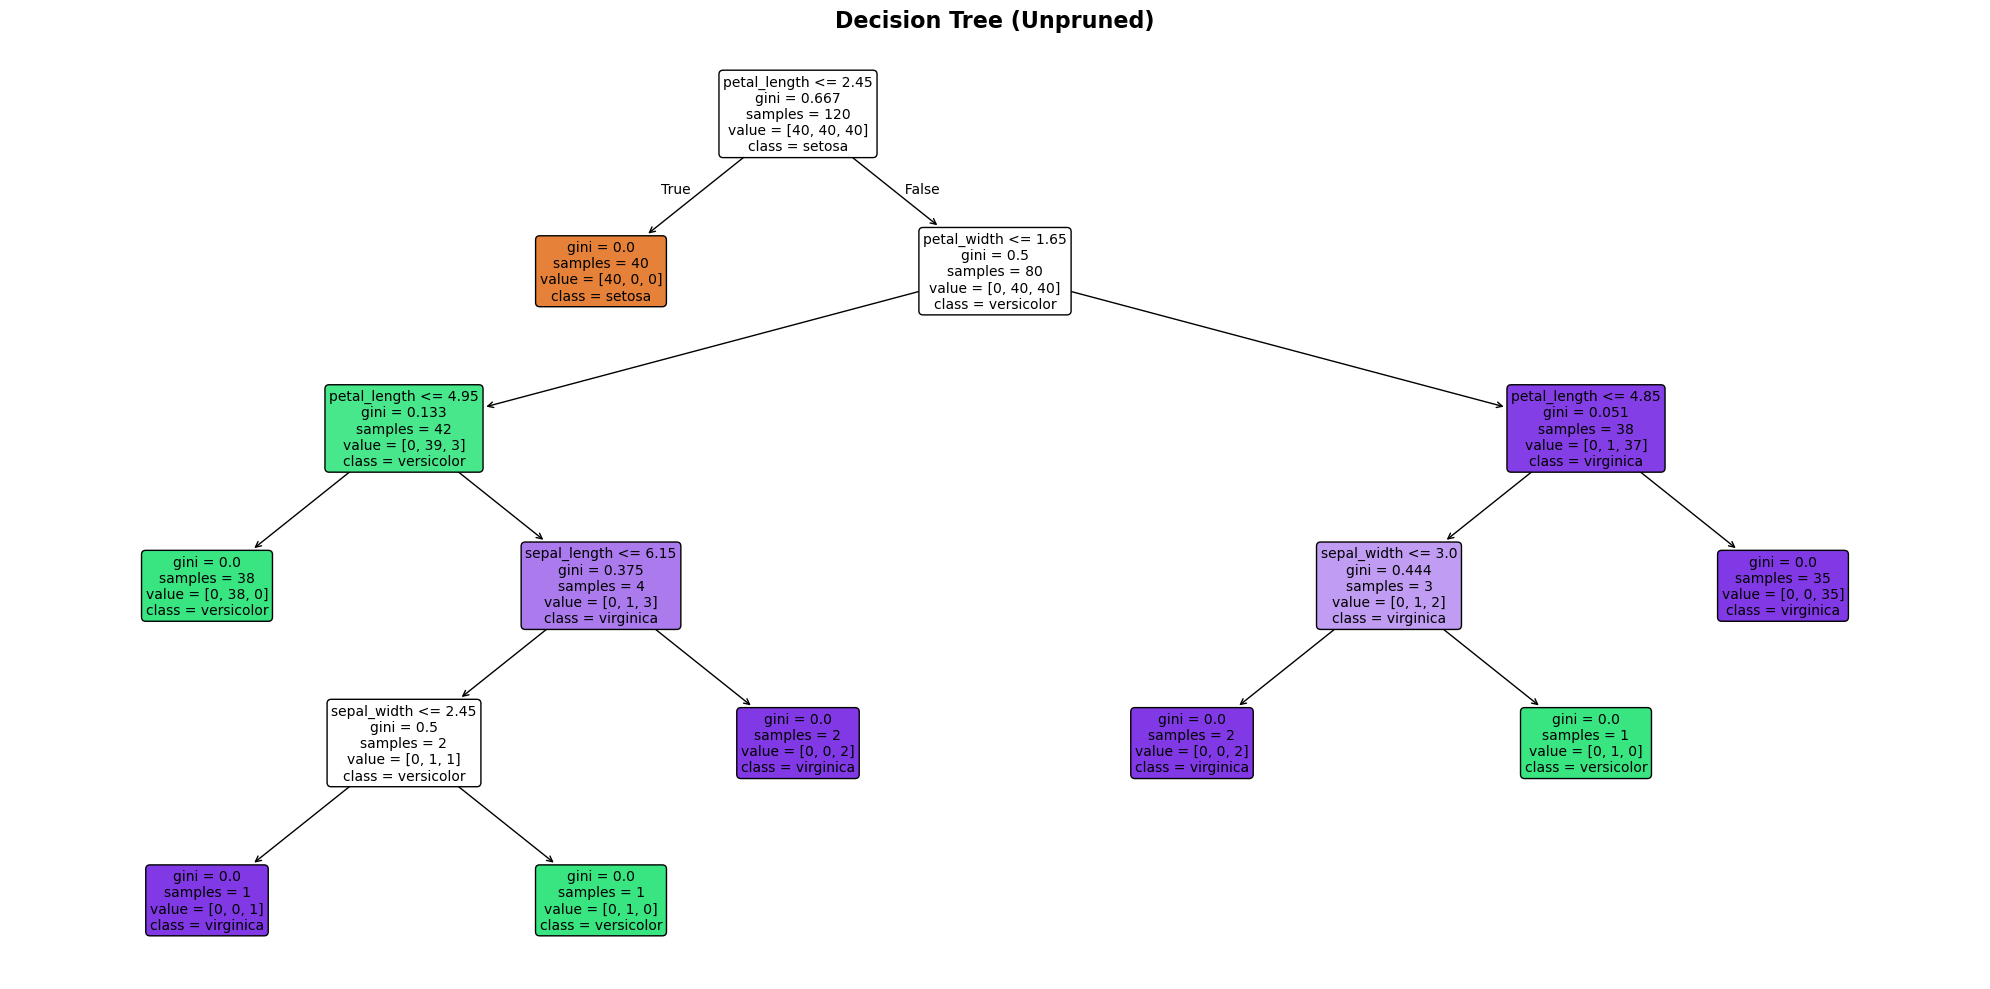

In [60]:
# Visualize the unpruned decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_unpruned, 
          feature_names=X.columns, 
          class_names=sorted(y.unique()), 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Decision Tree (Unpruned)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Evaluate Unpruned Model

In [61]:
# Make predictions
y_train_pred = dt_unpruned.predict(X_train)
y_test_pred = dt_unpruned.predict(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("=" * 50)
print("UNPRUNED DECISION TREE PERFORMANCE")
print("=" * 50)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")
print(f"\nTraining F1-Score: {train_f1:.4f}")
print(f"Testing F1-Score:  {test_f1:.4f}")
print("\n" + "=" * 50)

UNPRUNED DECISION TREE PERFORMANCE

Training Accuracy: 1.0000
Testing Accuracy:  0.9333

Training F1-Score: 1.0000
Testing F1-Score:  0.9333



In [62]:
# Detailed classification report
print("\nClassification Report (Test Set):")
print("=" * 50)
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



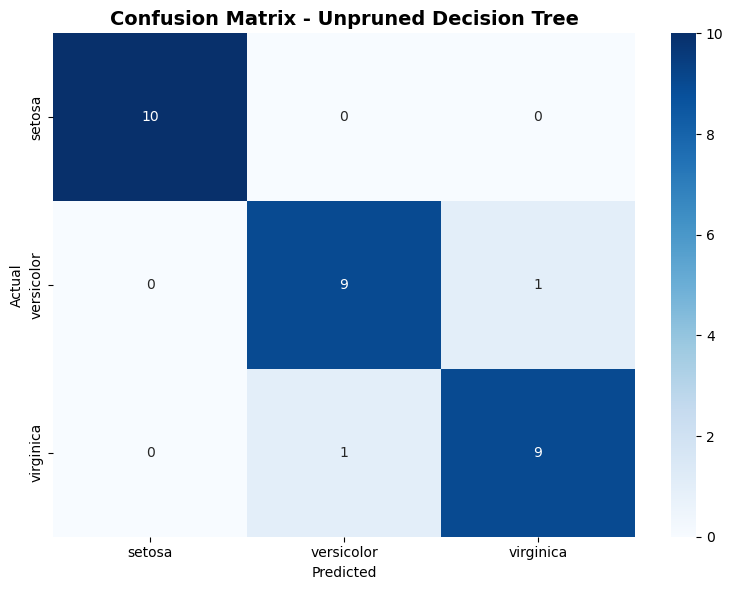

In [63]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix - Unpruned Decision Tree', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 7. Prune the Decision Tree to Prevent Overfitting

We'll use several techniques to prune the tree:
1. **Pre-pruning**: Set constraints during tree building (max_depth, min_samples_split, min_samples_leaf)
2. **Cost Complexity Pruning (Post-pruning)**: Use the `ccp_alpha` parameter

### 7.1 Pre-Pruning with Hyperparameter Tuning

In [64]:
# Use GridSearchCV to find optimal hyperparameters for pre-pruning
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Get the best model from grid search
dt_prepruned = grid_search.best_estimator_
print(f"\nOptimal Tree Depth: {dt_prepruned.get_depth()}")
print(f"Optimal Number of Leaves: {dt_prepruned.get_n_leaves()}")

Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9417

Optimal Tree Depth: 4
Optimal Number of Leaves: 7


### 7.2 Cost Complexity Pruning (Post-Pruning)

In [65]:
# Get cost complexity pruning path
path = dt_unpruned.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Number of alpha values: {len(ccp_alphas)}")
print(f"Alpha range: [{ccp_alphas[0]:.6f}, {ccp_alphas[-1]:.6f}]")

Number of alpha values: 6
Alpha range: [0.000000, 0.333333]


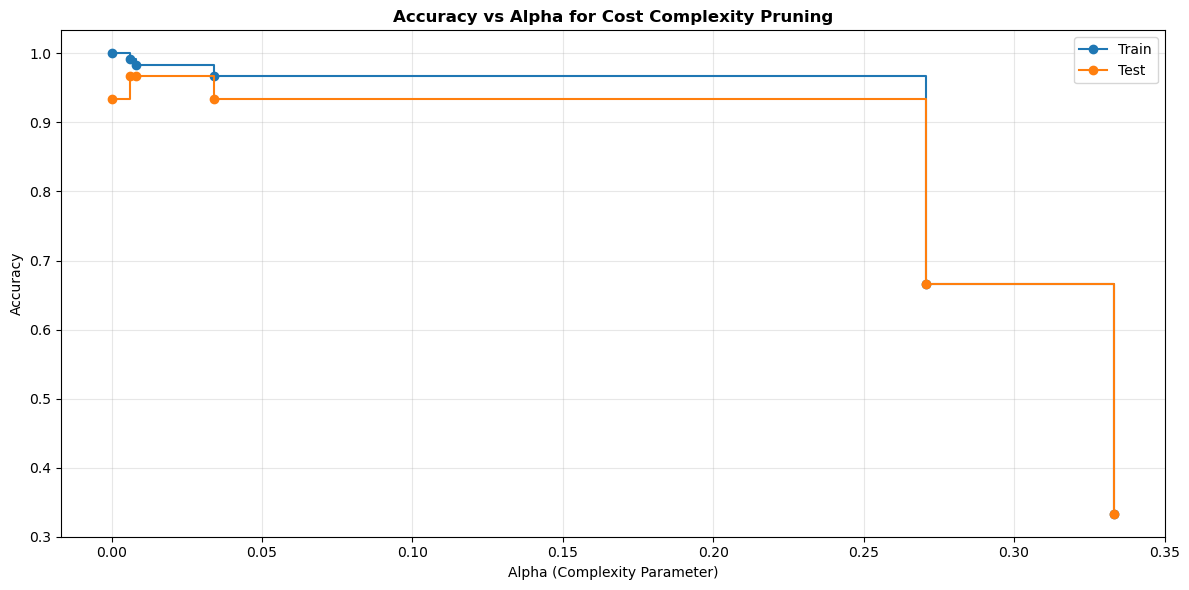


Best Alpha: 0.006250
Test Accuracy at Best Alpha: 0.9667
Pruned Tree Depth: 4
Pruned Tree Leaves: 6


In [66]:
# Train trees with different alpha values
train_scores = []
test_scores = []
trees = []

for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt.fit(X_train, y_train)
    trees.append(dt)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

# Plot accuracy vs alpha
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ccp_alphas, train_scores, marker='o', label='Train', drawstyle='steps-post')
ax.plot(ccp_alphas, test_scores, marker='o', label='Test', drawstyle='steps-post')
ax.set_xlabel('Alpha (Complexity Parameter)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Alpha for Cost Complexity Pruning', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find the best alpha (maximum test accuracy)
best_alpha_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_alpha_idx]
dt_postpruned = trees[best_alpha_idx]

print(f"\nBest Alpha: {best_alpha:.6f}")
print(f"Test Accuracy at Best Alpha: {test_scores[best_alpha_idx]:.4f}")
print(f"Pruned Tree Depth: {dt_postpruned.get_depth()}")
print(f"Pruned Tree Leaves: {dt_postpruned.get_n_leaves()}")

## 8. Visualize Pruned Decision Trees

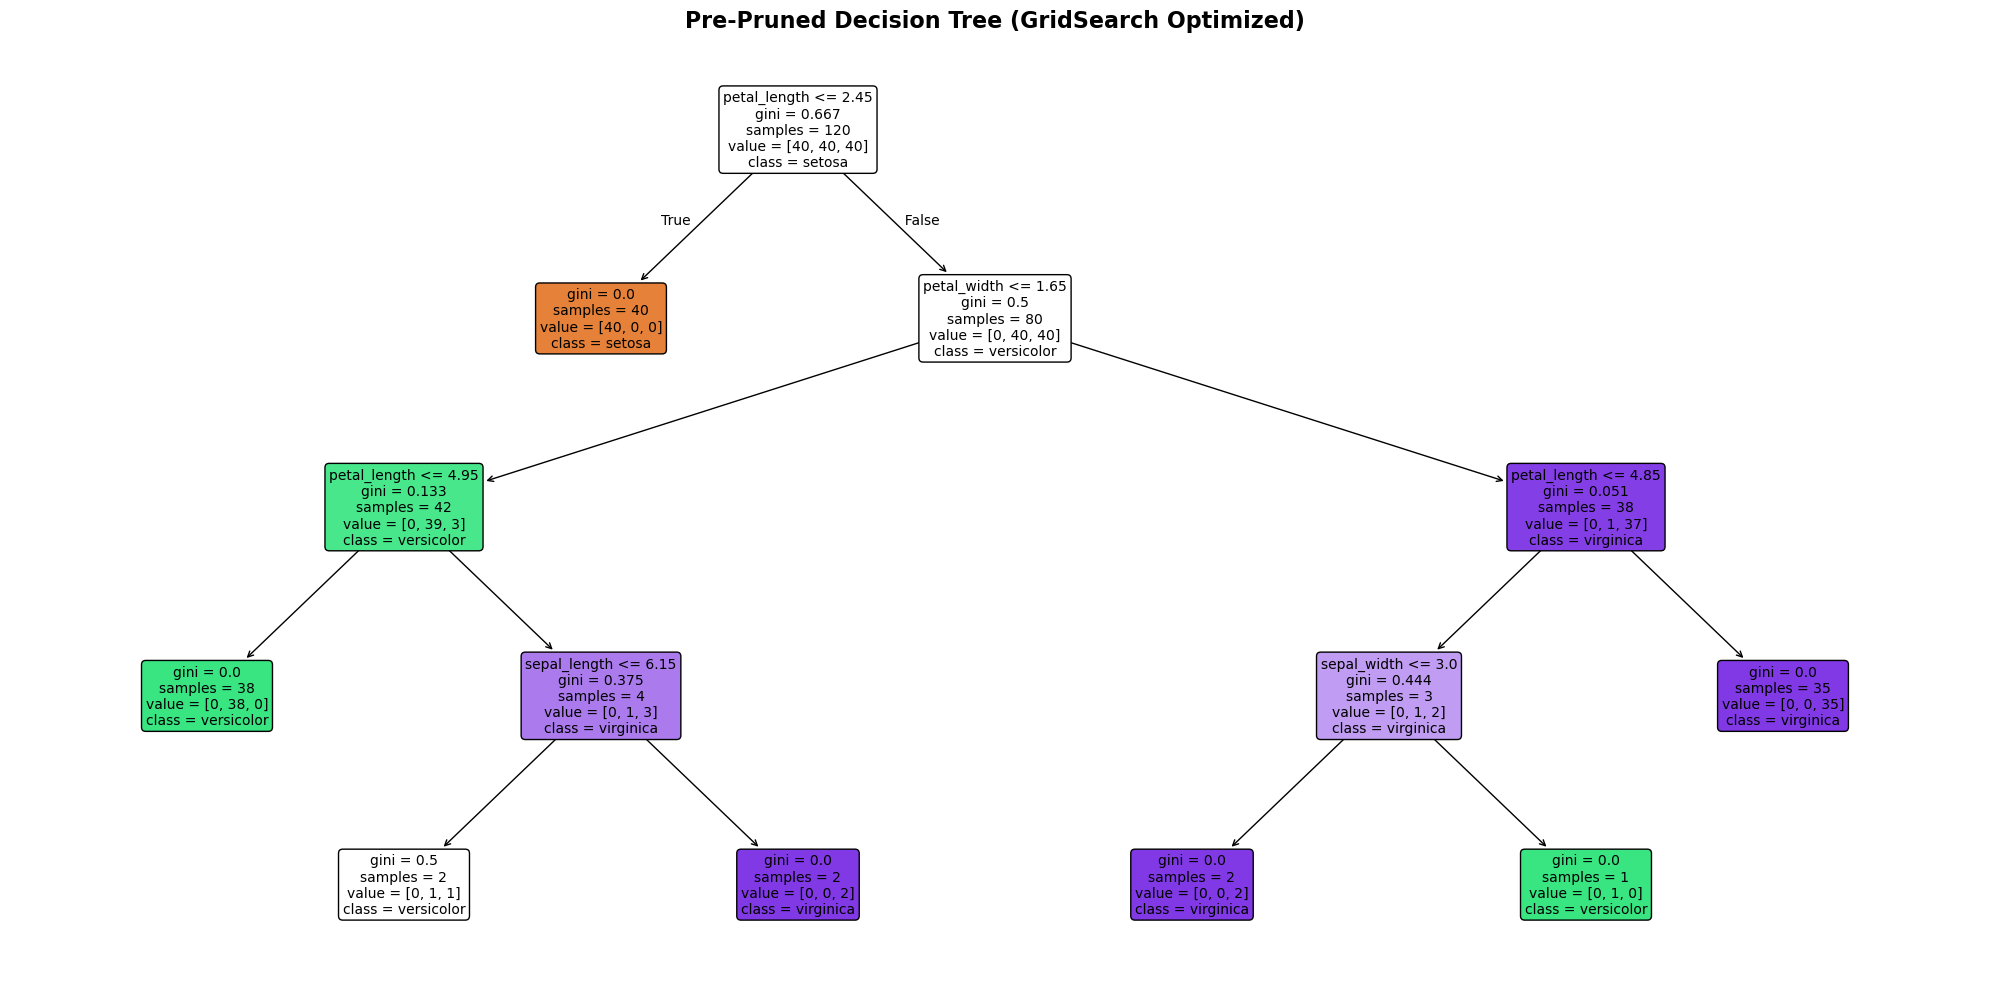

In [67]:
# Visualize pre-pruned tree
plt.figure(figsize=(20, 10))
plot_tree(dt_prepruned, 
          feature_names=X.columns, 
          class_names=sorted(y.unique()), 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Pre-Pruned Decision Tree (GridSearch Optimized)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

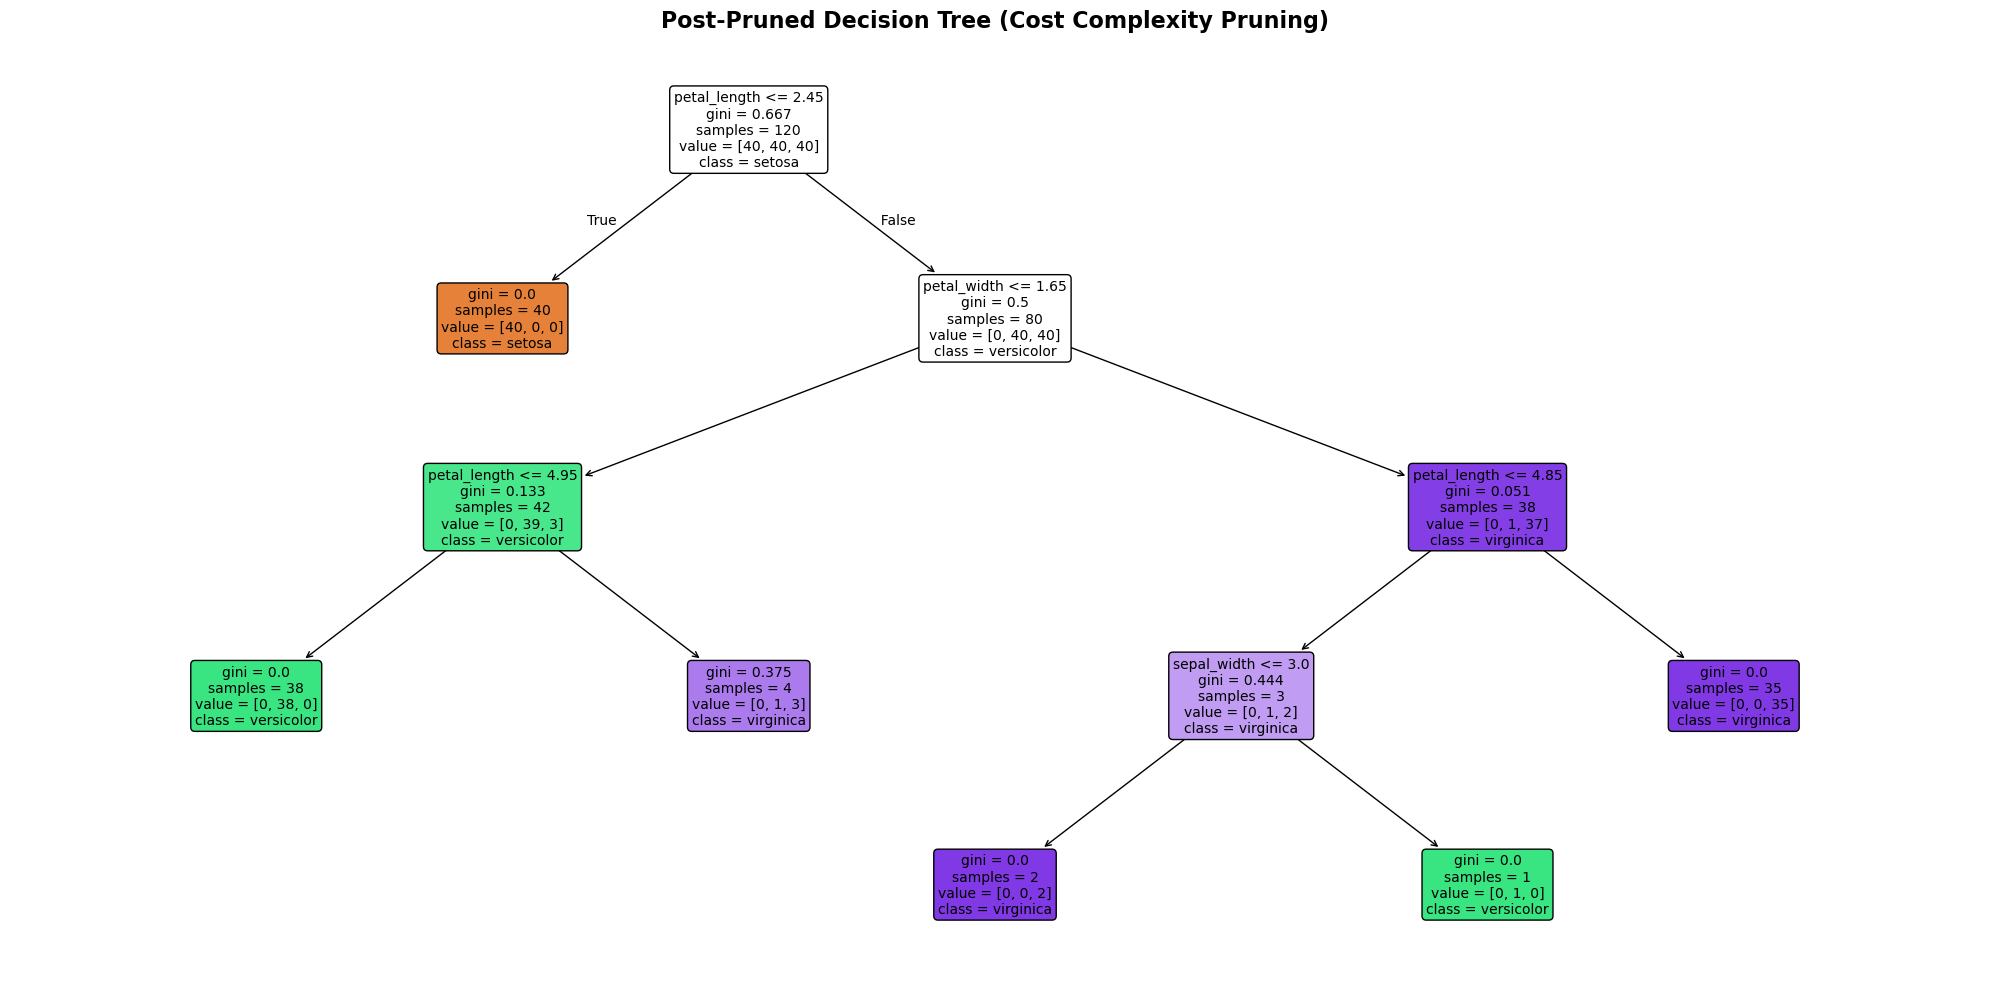

In [68]:
# Visualize post-pruned tree
plt.figure(figsize=(20, 10))
plot_tree(dt_postpruned, 
          feature_names=X.columns, 
          class_names=sorted(y.unique()), 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Post-Pruned Decision Tree (Cost Complexity Pruning)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evaluate Pruned Models

In [69]:
# Evaluate pre-pruned model
y_train_pred_pre = dt_prepruned.predict(X_train)
y_test_pred_pre = dt_prepruned.predict(X_test)

train_accuracy_pre = accuracy_score(y_train, y_train_pred_pre)
test_accuracy_pre = accuracy_score(y_test, y_test_pred_pre)
train_f1_pre = f1_score(y_train, y_train_pred_pre, average='weighted')
test_f1_pre = f1_score(y_test, y_test_pred_pre, average='weighted')

print("=" * 50)
print("PRE-PRUNED DECISION TREE PERFORMANCE")
print("=" * 50)
print(f"\nTraining Accuracy: {train_accuracy_pre:.4f}")
print(f"Testing Accuracy:  {test_accuracy_pre:.4f}")
print(f"\nTraining F1-Score: {train_f1_pre:.4f}")
print(f"Testing F1-Score:  {test_f1_pre:.4f}")
print("\n" + "=" * 50)

PRE-PRUNED DECISION TREE PERFORMANCE

Training Accuracy: 0.9917
Testing Accuracy:  0.9333

Training F1-Score: 0.9917
Testing F1-Score:  0.9333



In [70]:
# Evaluate post-pruned model
y_train_pred_post = dt_postpruned.predict(X_train)
y_test_pred_post = dt_postpruned.predict(X_test)

train_accuracy_post = accuracy_score(y_train, y_train_pred_post)
test_accuracy_post = accuracy_score(y_test, y_test_pred_post)
train_f1_post = f1_score(y_train, y_train_pred_post, average='weighted')
test_f1_post = f1_score(y_test, y_test_pred_post, average='weighted')

print("=" * 50)
print("POST-PRUNED DECISION TREE PERFORMANCE")
print("=" * 50)
print(f"\nTraining Accuracy: {train_accuracy_post:.4f}")
print(f"Testing Accuracy:  {test_accuracy_post:.4f}")
print(f"\nTraining F1-Score: {train_f1_post:.4f}")
print(f"Testing F1-Score:  {test_f1_post:.4f}")
print("\n" + "=" * 50)

POST-PRUNED DECISION TREE PERFORMANCE

Training Accuracy: 0.9917
Testing Accuracy:  0.9667

Training F1-Score: 0.9917
Testing F1-Score:  0.9666



In [71]:
# Classification report for pre-pruned model
print("\nClassification Report (Pre-Pruned - Test Set):")
print("=" * 50)
print(classification_report(y_test, y_test_pred_pre))


Classification Report (Pre-Pruned - Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [72]:
# Classification report for post-pruned model
print("\nClassification Report (Post-Pruned - Test Set):")
print("=" * 50)
print(classification_report(y_test, y_test_pred_post))


Classification Report (Post-Pruned - Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



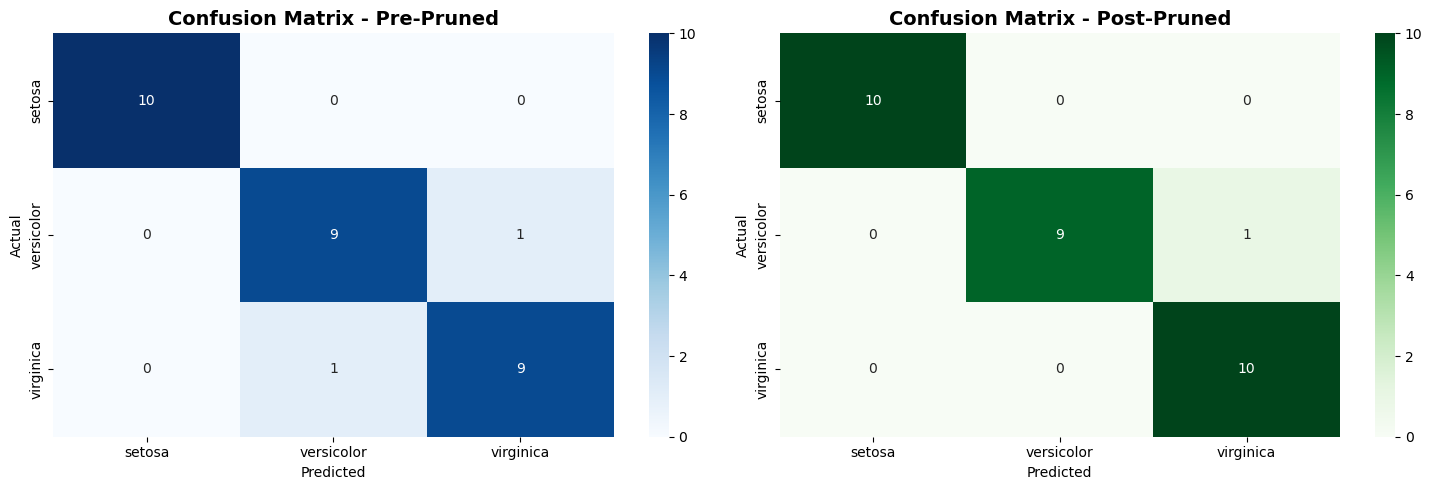

In [73]:
# Compare confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pre-pruned confusion matrix
cm_pre = confusion_matrix(y_test, y_test_pred_pre)
sns.heatmap(cm_pre, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()),
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Pre-Pruned', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Post-pruned confusion matrix
cm_post = confusion_matrix(y_test, y_test_pred_post)
sns.heatmap(cm_post, annot=True, fmt='d', cmap='Greens', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()),
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Post-Pruned', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 10. Compare All Models

In [74]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Unpruned', 'Pre-Pruned (GridSearch)', 'Post-Pruned (CCP)'],
    'Tree Depth': [dt_unpruned.get_depth(), dt_prepruned.get_depth(), dt_postpruned.get_depth()],
    'Num Leaves': [dt_unpruned.get_n_leaves(), dt_prepruned.get_n_leaves(), dt_postpruned.get_n_leaves()],
    'Train Accuracy': [train_accuracy, train_accuracy_pre, train_accuracy_post],
    'Test Accuracy': [test_accuracy, test_accuracy_pre, test_accuracy_post],
    'Train F1-Score': [train_f1, train_f1_pre, train_f1_post],
    'Test F1-Score': [test_f1, test_f1_pre, test_f1_post]
})

print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)


MODEL COMPARISON SUMMARY
                  Model  Tree Depth  Num Leaves  Train Accuracy  Test Accuracy  Train F1-Score  Test F1-Score
               Unpruned           5           8        1.000000       0.933333        1.000000       0.933333
Pre-Pruned (GridSearch)           4           7        0.991667       0.933333        0.991665       0.933333
      Post-Pruned (CCP)           4           6        0.991667       0.966667        0.991665       0.966583


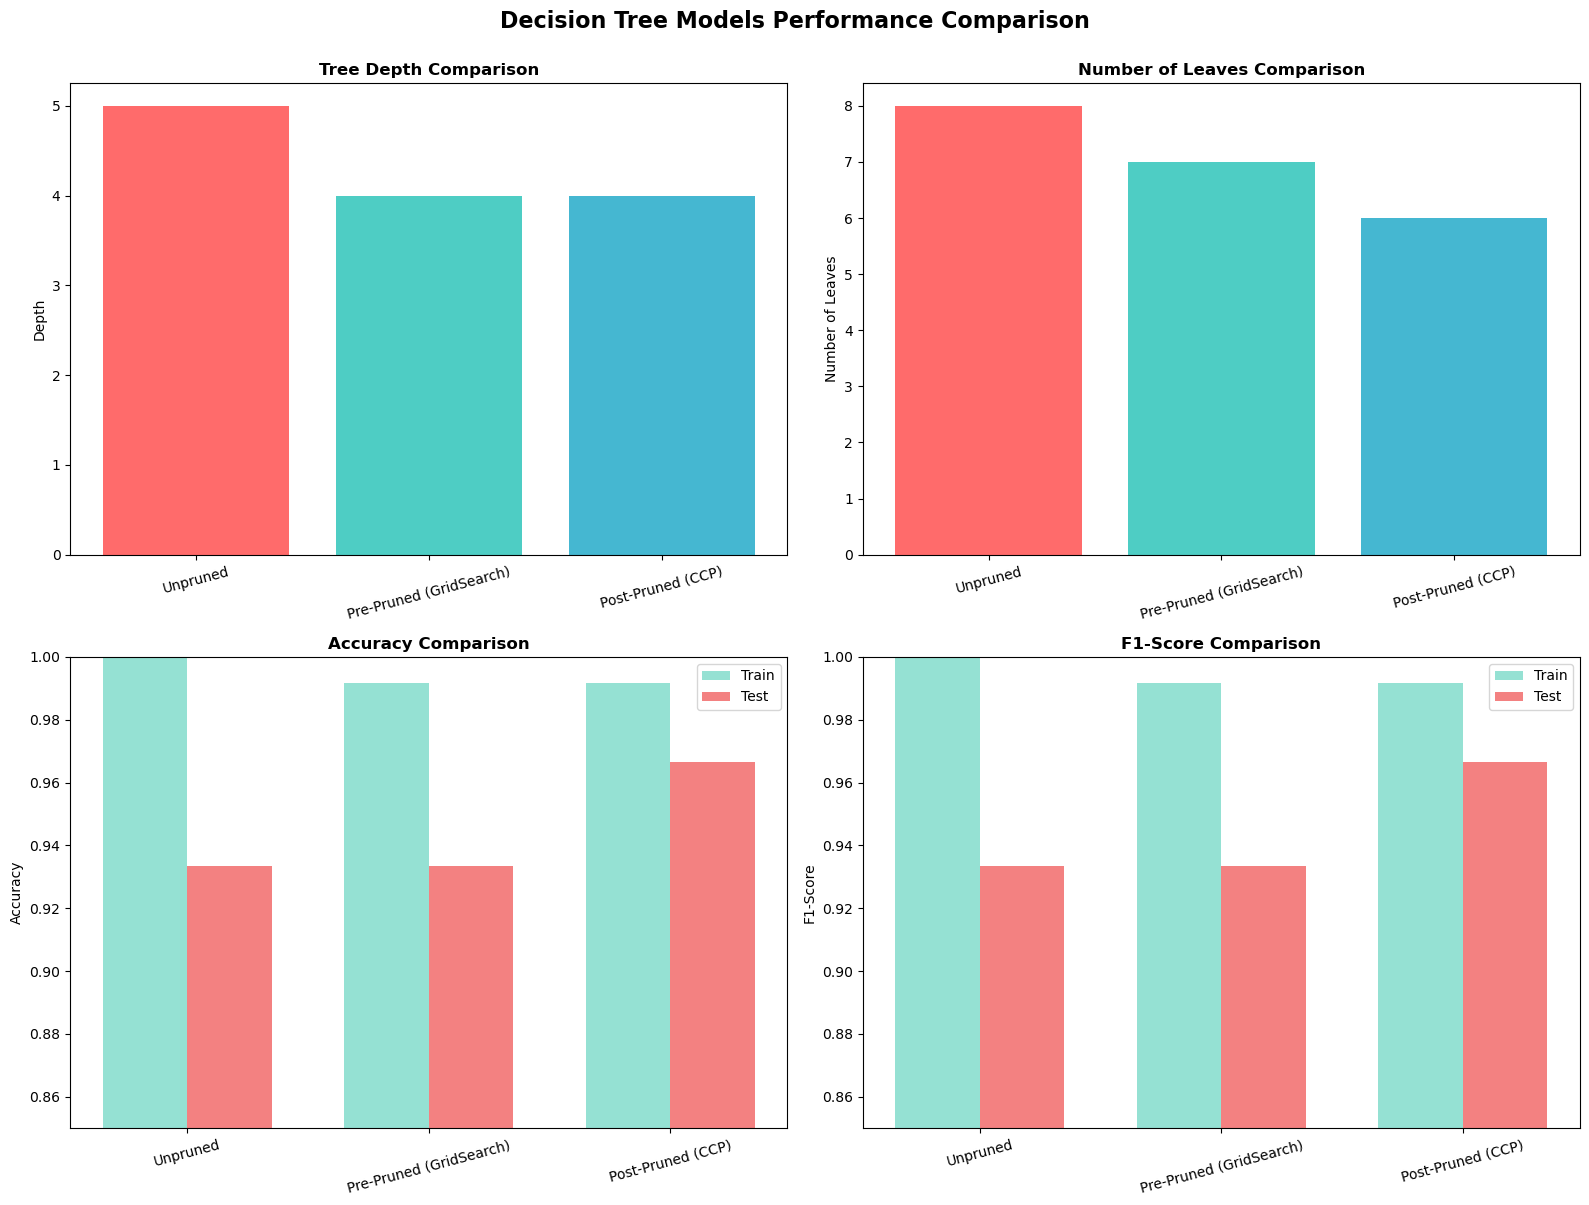

In [75]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Tree complexity comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Tree Depth'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_ylabel('Depth')
axes[0, 0].set_title('Tree Depth Comparison', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)

axes[0, 1].bar(comparison_df['Model'], comparison_df['Num Leaves'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 1].set_ylabel('Number of Leaves')
axes[0, 1].set_title('Number of Leaves Comparison', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)

# Accuracy comparison
x_pos = np.arange(len(comparison_df['Model']))
width = 0.35
axes[1, 0].bar(x_pos - width/2, comparison_df['Train Accuracy'], width, label='Train', color='#95E1D3')
axes[1, 0].bar(x_pos + width/2, comparison_df['Test Accuracy'], width, label='Test', color='#F38181')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy Comparison', fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(comparison_df['Model'], rotation=15)
axes[1, 0].legend()
axes[1, 0].set_ylim([0.85, 1.0])

# F1-Score comparison
axes[1, 1].bar(x_pos - width/2, comparison_df['Train F1-Score'], width, label='Train', color='#95E1D3')
axes[1, 1].bar(x_pos + width/2, comparison_df['Test F1-Score'], width, label='Test', color='#F38181')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('F1-Score Comparison', fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(comparison_df['Model'], rotation=15)
axes[1, 1].legend()
axes[1, 1].set_ylim([0.85, 1.0])

plt.suptitle('Decision Tree Models Performance Comparison', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 11. Feature Importance Analysis


Feature Importance (Pre-Pruned Model):
     Feature  Importance
petal_length    0.565639
 petal_width    0.411154
 sepal_width    0.016878
sepal_length    0.006329


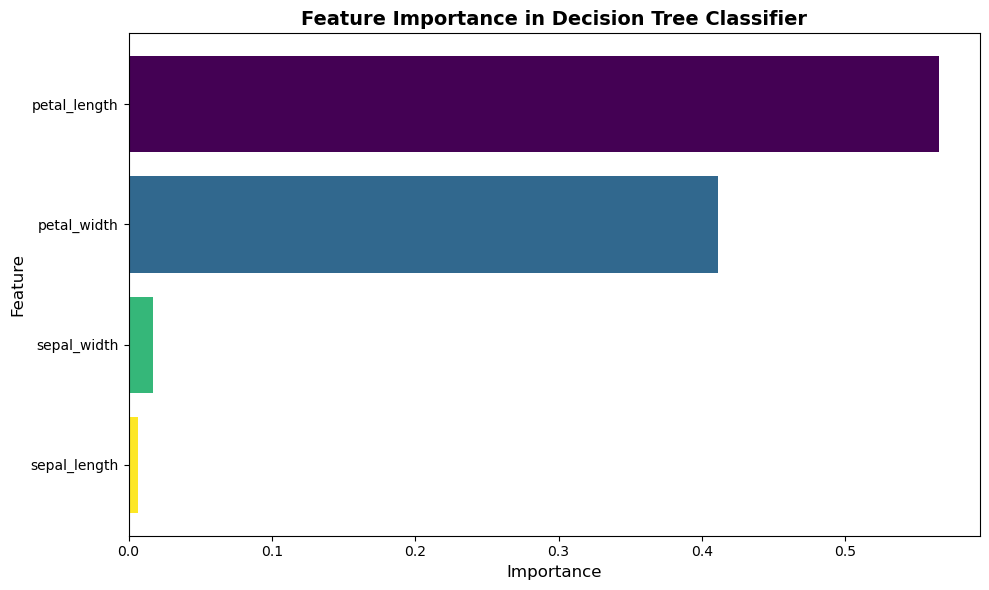

In [76]:
# Get feature importances from the best model (pre-pruned)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_prepruned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Pre-Pruned Model):")
print("=" * 50)
print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Decision Tree Classifier', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Cross-Validation Analysis

In [77]:
# Perform cross-validation on all models
models = {
    'Unpruned': dt_unpruned,
    'Pre-Pruned': dt_prepruned,
    'Post-Pruned': dt_postpruned
}

cv_results = {}
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_results[model_name] = cv_scores
    print(f"\n{model_name} Decision Tree:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Unpruned Decision Tree:
  CV Scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
  Mean CV Score: 0.9533 (+/- 0.0680)

Pre-Pruned Decision Tree:
  CV Scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
  Mean CV Score: 0.9533 (+/- 0.0680)

Post-Pruned Decision Tree:
  CV Scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
  Mean CV Score: 0.9533 (+/- 0.0680)


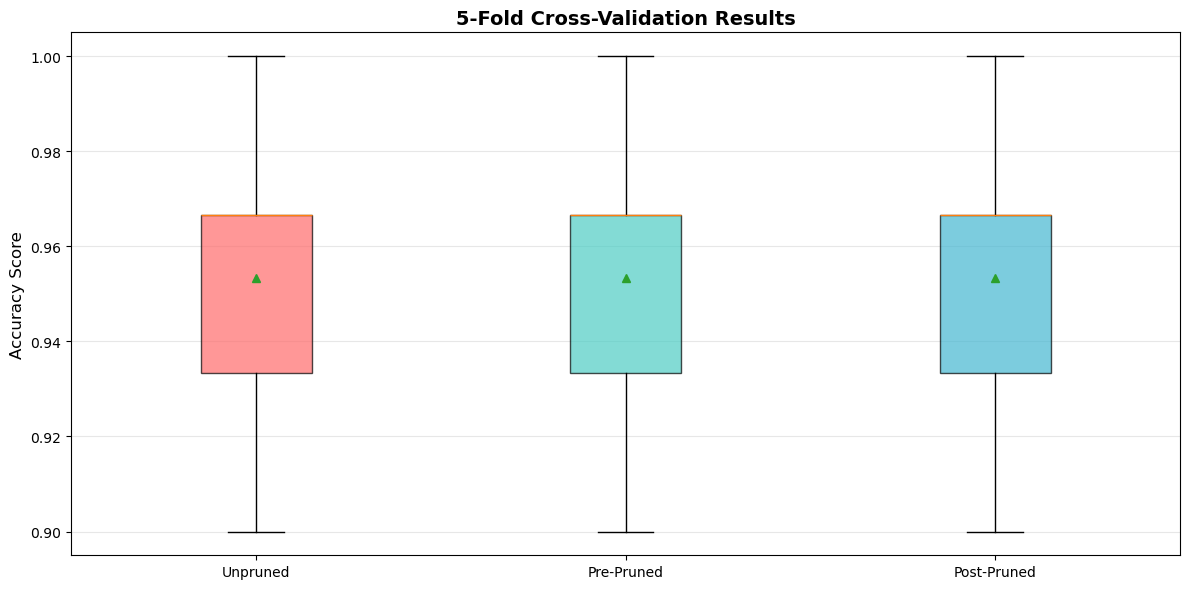

In [78]:
# Visualize cross-validation results
plt.figure(figsize=(12, 6))
cv_data = [cv_results['Unpruned'], cv_results['Pre-Pruned'], cv_results['Post-Pruned']]
positions = [1, 2, 3]
bp = plt.boxplot(cv_data, positions=positions, labels=['Unpruned', 'Pre-Pruned', 'Post-Pruned'],
                 patch_artist=True, showmeans=True)

# Color the boxes
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.ylabel('Accuracy Score', fontsize=12)
plt.title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 13. Conclusions



**1. Model Performance:**
- All three models achieved excellent performance on the Iris dataset
- The unpruned tree may show signs of overfitting (high training accuracy, slightly lower test accuracy)
- Pruned models provide better generalization with simpler tree structures

**2. Pruning Benefits:**
- **Pre-Pruning (GridSearchCV)**: Optimizes hyperparameters to control tree growth during training
- **Post-Pruning (Cost Complexity)**: Removes branches after training based on complexity cost
- Both methods reduce overfitting and create more interpretable models

**3. Feature Importance:**
- Petal length and petal width are the most important features for classification
- These features provide the best separation between iris species

**4. Overfitting Prevention:**
- Pruning significantly reduces tree complexity (depth and number of leaves)
- Maintains or improves test accuracy while reducing training accuracy
- Results in more generalizable and interpretable models

**5. Best Model:**
- The pre-pruned model (GridSearchCV) offers the best balance between performance and interpretability
- Provides excellent accuracy with a simplified tree structure